# Movie Color-Mood Analysis — Exploration

Interactive analysis and figure generation.

In [1]:
# Source - https://stackoverflow.com/a/66991145
# Posted by R Kumar
# Retrieved 2026-04-27, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [2]:
import json
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.color_extraction import compute_summary_stats
from src.analysis import build_emd_matrix, build_feature_matrix, embed_scenes
from src.visualization import (
    plot_movie_barcode, plot_palette_strip, plot_polar_hue,
    plot_mood_timeline, plot_embedding,
)

%matplotlib inline
sns.set_theme(style="whitegrid")

## Load Data

Update the paths below to point to your pipeline outputs.

In [3]:
FILM = "spiderman"  # Change this
BASE_DIR = os.path.dirname( os.getcwd())
OUTPUT_DIR = os.path.join( BASE_DIR, f"data/outputs/{FILM}")

with open(OUTPUT_DIR + "/palettes.json") as f:
    palettes_data = json.load(f)["palettes"]

with open(BASE_DIR + f"/data/annotations/{FILM}.json") as f:
    annotations = json.load(f)

mood_labels = [s["mood_label"] for s in annotations["scenes"]]
print(f"Loaded {len(palettes_data)} scenes, {len(set(mood_labels))} mood categories")

Loaded 1015 scenes, 8 mood categories


## Movie Barcode

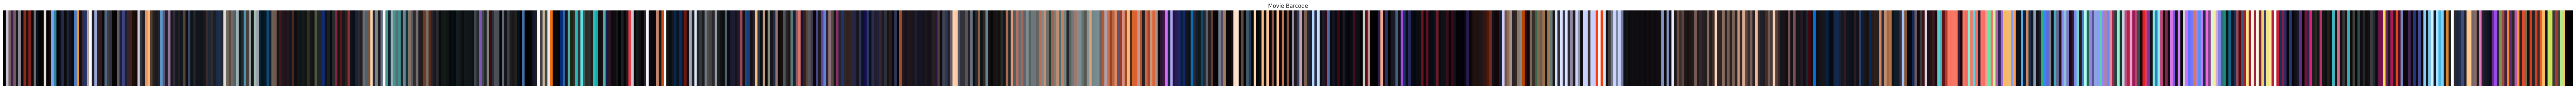

In [4]:
plot_movie_barcode(palettes_data);

## EMD Embedding by Mood

Building EMD matrix: 100%|████████| 1015/1015 [01:13<00:00, 13.72it/s]


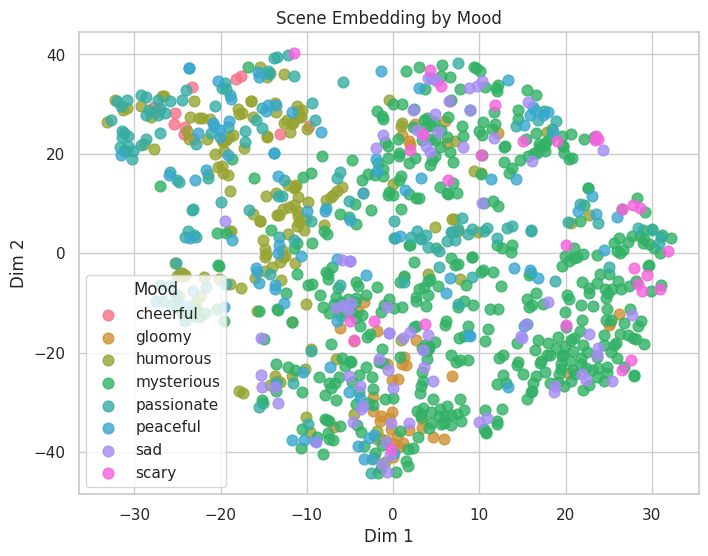

In [5]:
emd_matrix = build_emd_matrix(palettes_data)
coords = embed_scenes(emd_matrix, method="tsne")
plot_embedding(coords, mood_labels);

## Mood Timeline

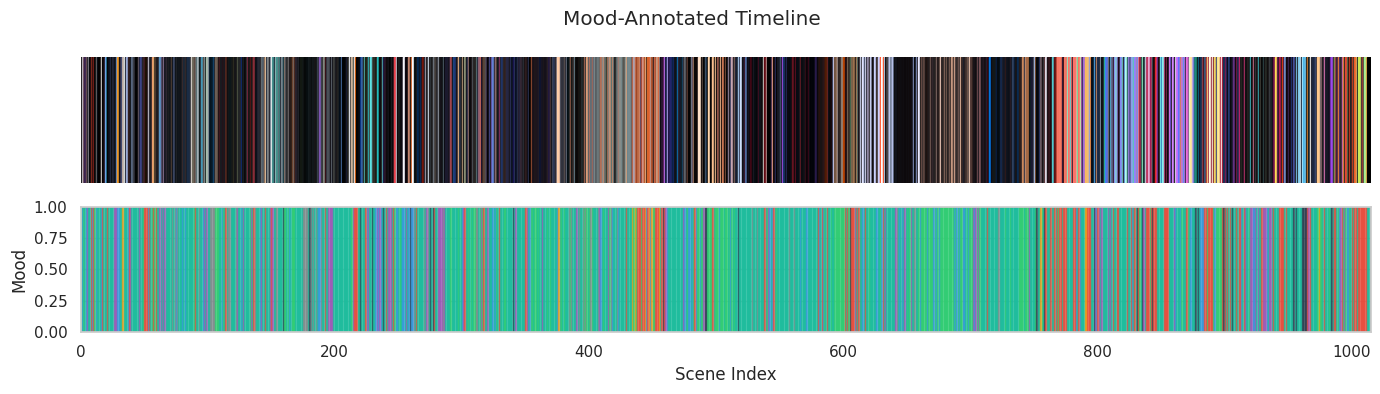

In [6]:
plot_mood_timeline(palettes_data, annotations["scenes"]);